In [2]:
# import libraries
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


In [3]:
# lets import the dataset (here we are gonna use processed_datatcsv)
df = pd.read_csv("processed_data.csv")

In [4]:
# lets drop the columns
df.drop(columns = "Unnamed: 0",inplace = True)

In [5]:
# lets do train test split
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(df.drop("status", axis=1),df["status"],test_size = 0.2,random_state=1)

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer

num_cols = ["statement_length", "num_words", "vocabulary_size", "avg_word_length"]

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(max_features=15000), "clean_text"),   # preprocessed text
    ("num", StandardScaler(), num_cols)             # numeric features
])

In [7]:
# lets import the model
import lightgbm as lgb

In [8]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

lgbm_pipeline = Pipeline([
    ("preprocess", preprocessor),  # your existing ColumnTransformer
    ("model", LGBMClassifier(
        objective="multiclass",
        num_class=7,
        random_state=42,
        n_jobs=-1
    ))
])

In [9]:
lgbm_pipeline.fit(xtrain, ytrain)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.319843 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 332199
[LightGBM] [Info] Number of data points in the train set: 42036, number of used features: 6210
[LightGBM] [Info] Start training from score -1.179595
[LightGBM] [Info] Start training from score -1.227871
[LightGBM] [Info] Start training from score -1.595523
[LightGBM] [Info] Start training from score -2.607447
[LightGBM] [Info] Start training from score -2.930266
[LightGBM] [Info] Start training from score -3.008565
[LightGBM] [Info] Start training from score -3.891678


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=15000),
                                                  'clean_text'),
                                                 ('num', StandardScaler(),
                                                  ['statement_length',
                                                   'num_words',
                                                   'vocabulary_size',
                                                   'avg_word_length'])])),
                ('model',
                 LGBMClassifier(n_jobs=-1, num_class=7, objective='multiclass',
                                random_state=42))])

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      3291
           1       0.71      0.74      0.73      3090
           2       0.70      0.66      0.68      2122
           3       0.79      0.80      0.79       742
           4       0.89      0.78      0.83       533
           5       0.69      0.51      0.59       512
           6       0.89      0.65      0.75       219

    accuracy                           0.78     10509
   macro avg       0.79      0.73      0.75     10509
weighted avg       0.78      0.78      0.78     10509



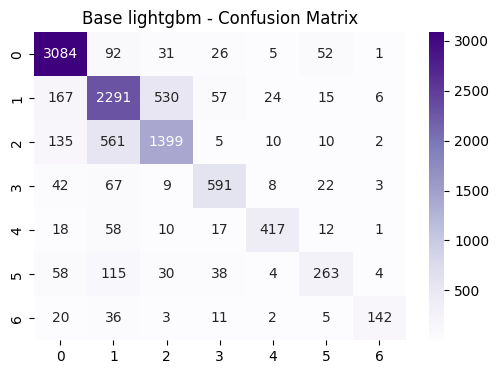

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = lgbm_pipeline.predict(xtest)

print(classification_report(ytest, y_pred))

cm = confusion_matrix(ytest, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples")
plt.title("Base lightgbm - Confusion Matrix")
plt.show()

In [11]:
# i can clearly observe that lightgbm id clearly outperforming the other models in this basic tunning 
# also it takes less than a minute while training but while other models takes 10 to 12 minutes 
